In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping

2026-04-08 13:33:05.671865: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775655186.013085      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775655186.089637      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775655186.815452      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775655186.815516      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775655186.815519      55 computation_placer.cc:177] computation placer alr

In [2]:
df = pd.read_csv("/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv")
print(df.head())

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [3]:
df = df[['review', 'sentiment']]
print(df.head())

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [4]:
le = LabelEncoder()
df['sentiment'] = le.fit_transform(df['sentiment'])
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'negative': np.int64(0), 'positive': np.int64(1)}


In [5]:
print(df['sentiment'].value_counts())

sentiment
1    25000
0    25000
Name: count, dtype: int64


In [6]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', '', text)        # remove HTML tags like <br />
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z ]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['review'] = df['review'].fillna('').astype(str)
df['review'] = df['review'].apply(clean_text)

In [7]:
print(df['review'].isnull().sum())

0


In [8]:
VOCAB_SIZE = 20000
MAX_LEN = 300

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(df['review'])

X = pad_sequences(
    tokenizer.texts_to_sequences(df['review']),
    maxlen=MAX_LEN,
    truncating='post',
    padding='post'
)

y = df['sentiment'].values

print(X.shape)

(50000, 300)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)

(40000, 300) (10000, 300)


In [10]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [11]:
lstm_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=128, input_length=MAX_LEN),
    SpatialDropout1D(0.2),
    LSTM(128, dropout=0.2, recurrent_dropout=0.2),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')   # binary: positive / negative
])

lstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1775655239.811809      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
history = lstm_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 395s 1s/step - accuracy: 0.5036 - loss: 0.6935 - val_accuracy: 0.4951 - val_loss: 0.6932
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 351s 1s/step - accuracy: 0.5312 - loss: 0.6807 - val_accuracy: 0.5131 - val_loss: 0.6818
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 336s 1s/step - accuracy: 0.5618 - loss: 0.6473 - val_accuracy: 0.5555 - val_loss: 0.6654
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 336s 1s/step - accuracy: 0.5753 - loss: 0.6258 - val_accuracy: 0.5368 - val_loss: 0.6747
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 332s 1s/step - accuracy: 0.6060 - loss: 0.6043 - val_accuracy: 0.8071 - val_loss: 0.4653
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 391s 1s/step - accuracy: 0.7945 - loss: 0.4733 - val_accuracy: 0.8217 - val_loss: 0.4507
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 358s 1s/step - accuracy: 0.8635 - loss: 0.3426 - val_accuracy: 0.8536 - val_loss: 0.3955
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 355s 1s/step - accuracy: 0.8995 - loss: 0.2638 - val_accu

In [13]:
loss, acc = lstm_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss     : {loss:.4f}")
print(f"Test Accuracy : {acc:.4f}")

Test Loss     : 0.3457
Test Accuracy : 0.8556


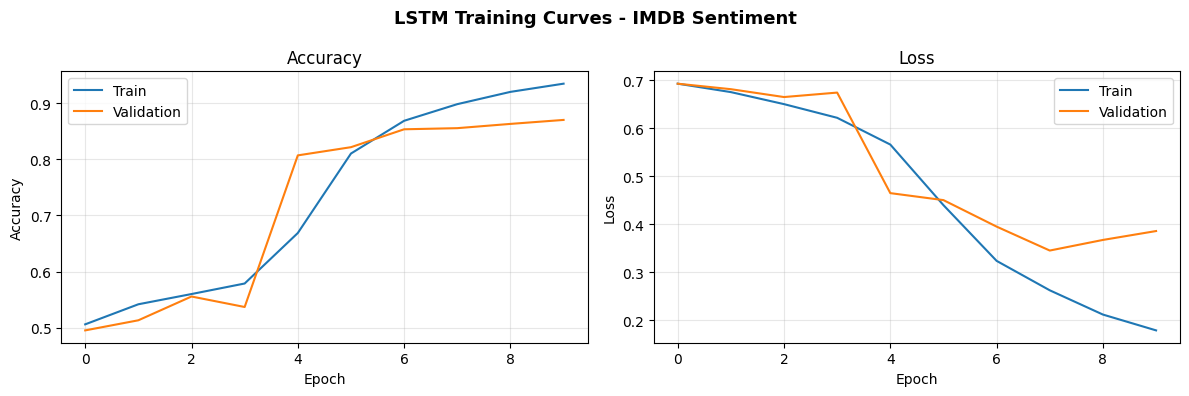

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('LSTM Training Curves - IMDB Sentiment', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

    negative       0.83      0.89      0.86      5000
    positive       0.88      0.82      0.85      5000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



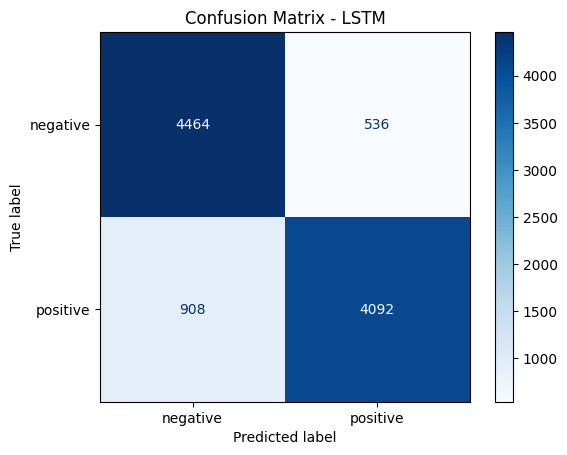

In [15]:
y_pred = (lstm_model.predict(X_test, verbose=0) >= 0.5).astype(int).flatten()

print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - LSTM')
plt.show()

In [16]:
def predict_sentiment(text):
    cleaned = clean_text(text)
    seq = pad_sequences(
        tokenizer.texts_to_sequences([cleaned]),
        maxlen=MAX_LEN, padding='post', truncating='post'
    )
    prob = lstm_model.predict(seq, verbose=0)[0][0]
    label = le.inverse_transform([int(prob >= 0.5)])[0]
    return label, round(float(prob), 4)

test_reviews = [
    "This movie was absolutely fantastic, one of the best I have ever seen!",
    "Terrible film. Boring plot and awful acting. Total waste of time.",
    "It was okay, nothing special but not bad either."
]

for review in test_reviews:
    label, prob = predict_sentiment(review)
    print(f"Review     : {review}")
    print(f"Prediction : {label} (confidence: {prob})")
    print()

Review     : This movie was absolutely fantastic, one of the best I have ever seen!
Prediction : positive (confidence: 0.8719)

Review     : Terrible film. Boring plot and awful acting. Total waste of time.
Prediction : negative (confidence: 0.0222)

Review     : It was okay, nothing special but not bad either.
Prediction : negative (confidence: 0.0721)

